# Phase 2 — Notebook 03 · Stage 2.2 · E0 trial-level feasibility (Design A)

**Scope.** Same population, same session **5_6**, same five `GroupKFold` folds as notebooks 01–02, but the input representation switches from E1 to E0:

$$
E_0 = \bigl\{(i, h, r)\bigr\} \quad\quad x_{i,h,r}\in\mathbb{R}^T
$$

i.e. one row per **(neuron, hash, trial)** instead of one row per (neuron, hash) within-hash mean. We do *not* average trials within hash before training (planning §2.2 / §2.3).

**Architecture.** Design A only — the same row-level `SmallTraceCNN` from notebook 01 (Conv1d 1→32→64 + masked GAP + 64→32→4 head). The point of Stage 2.2 is to test the *representation*, not the architecture. Design B on E0 (Stage 2.2 step 2 in §7) is the next notebook.

**Two aggregation modes for neuron-level scoring** (planning §6.2). For E0 every neuron has H = 116 oracle hashes with R_h ∈ {2, 10} trials each — 6 "true-oracle" Clip hashes carry 10 trials, the other 110 oracle hashes carry 2:

* **Row-uniform** $\;p_i(y)=\tfrac{1}{N_i}\sum_{h,r} p(y\mid x_{i,h,r})\;$ — every observed trial is one vote. Hashes with more reps contribute more weight.
* **Hash-uniform** $\;p_{i,h}(y)=\tfrac{1}{R_h}\sum_r p(y\mid x_{i,h,r}),\;p_i(y)=\tfrac{1}{H_i}\sum_h p_{i,h}(y)\;$ — first collapse trials within hash, then average across hashes. Each hash contributes equally.

We report **both** in this notebook and read the difference per planning §7-Stage 2.2:

| Comparison | Reading |
|---|---|
| E0 > E1 under **both** aggregations | trial-level variability / reliability carries useful information |
| E0 improves only under row-uniform | apparent gain reflects extra voting weight from repeated trials, not real trial information |
| E0 < E1 | trial noise dominates, trial averaging (E1) is preferable |
| E0 raw > E1 raw, but controls don't follow the same pattern | improvement is suspicious — re-examine before scaling |

**Methodological contract** (binding rules from `PHASE2_PLANNING.md`):

1. Working pool of V1 excitatory best-only neurons, mismatch-removed (§1.3).
2. Session 5_6, padded to T=113, masked GAP, no across-hash averaging, no within-neuron normalisation, no engineered tiers, no benchmark (§3.1, §4.3, §8).
3. **Same 5 `GroupKFold` folds by `nucleus_id`** as notebook 01/02 (deterministic given the same neuron set ⇒ paired E0 vs E1 deltas are exact at the fold/neuron level).
4. **Same four conditions** as notebook 01: `raw_identity`, `baseline_sub_identity`, `raw_time_shuffled`, `raw_amplitude_only`. Controls are applied per **trial** here (the natural E0 unit) so the input distribution matches what the CNN actually sees.
5. **Loss / optim** identical to notebook 01: class-weighted CE on unique training neurons, AdamW (lr=1e-3, wd=1e-4), CosineAnnealingLR. Larger batch (512) since E0 has ~2.4× more rows than E1.
6. **Scoring**: train on rows, score on neurons; report **both** row-uniform and hash-uniform aggregations.

Outputs: `data/processed/results/phase2_stage2_2_e0_design_a.parquet` (one row per `(condition × fold × aggregation)` plus summaries).

## 0 · Environment

In [1]:
import os, sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import GroupKFold

from src.config import PROCESSED_RESULTS_DIR
from src.data.loaders import load_working_pop
from src.features.raw_traces import (
    remove_mismatch_neurons,
    build_single_session_e0,
    baseline_subtract_traces,
    get_padded_arrays,
    make_time_shuffled_traces,
    make_amplitude_only_traces,
    MAX_TRACE_LEN,
)
from src.models.cnn import (
    train_fold, predict_proba, LAYER_CLASSES,
)
from src.eval.metrics import (
    neuron_level_score,
    neuron_level_score_hash_uniform,
)
from src.eval.cnn_eval import save_results, make_result_row

warnings.filterwarnings('ignore', category=UserWarning)

SEED       = 42
N_FOLDS    = 5
SESSION    = '5_6'
N_BASELINE = 5             # ≈ 0.67 s pre-stim @ 7.5 Hz (matches notebooks 01–02)
MAX_EPOCHS = 50
PATIENCE   = 8
BATCH_SIZE = 512           # 2× notebook 01 — E0 has ~2.4× more rows

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device       : {DEVICE}')
print(f'Project root : {PROJECT_ROOT}')
print(f'Pad length T : {MAX_TRACE_LEN}')
print(f'CV protocol  : GroupKFold(n_splits={N_FOLDS}) by nucleus_id  (matches notebooks 01–02)')
print(f'Architecture : SmallTraceCNN (Design A) — row-level row-by-row')
print(f'Aggregations : row-uniform AND hash-uniform (planning §6.2)')
print(f'Seed         : {SEED}')

Device       : mps
Project root : /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project
Pad length T : 113
CV protocol  : GroupKFold(n_splits=5) by nucleus_id  (matches notebooks 01–02)
Architecture : SmallTraceCNN (Design A) — row-level row-by-row
Aggregations : row-uniform AND hash-uniform (planning §6.2)
Seed         : 42


## 1 · Population & E0 dataset

In [2]:
units_raw = load_working_pop()
units_clean, mismatch_report = remove_mismatch_neurons(units_raw, verbose=False)
print(f"Population (after mismatch removal): {mismatch_report['n_clean']} / {mismatch_report['n_total']} "
      f"neurons ({100 - mismatch_report['pct_removed']:.1f}%)")

df_e0 = build_single_session_e0(SESSION, units_clean, verbose=True)

# Sanity contracts
assert df_e0['response'].notna().all()
assert set(df_e0['layer_label']).issubset({'L2/3','L4','L5','L6'})
rows_per_neuron = df_e0.groupby('nucleus_id').size()
assert rows_per_neuron.nunique() == 1, ('non-uniform rows-per-neuron — '
                                       'aggregation comparisons need uniform coverage')
n_neurons = df_e0['nucleus_id'].nunique()
print(f'\nNeurons : {n_neurons}')
print(f'Trial rows per neuron (uniform): {rows_per_neuron.iloc[0]}')
print(f'Total E0 rows: {len(df_e0):,}')
print('\nLayer distribution (per neuron):')
print(df_e0.drop_duplicates('nucleus_id')['layer_label'].value_counts().sort_index().to_string())
print('\nTrials per (neuron, hash) — distribution:')
print(df_e0.groupby(['nucleus_id','condition_hash']).size().value_counts().sort_index().to_string())

Population (after mismatch removal): 8488 / 8895 neurons (95.4%)
Session 5_6: 685 clean neurons
layer_label
L2/3    151
L4      249
L5      189
L6       96

E0 rows: 191,800
Neurons: 685   |   oracle hashes: 116
Trials per (neuron, hash): min=2 median=2 max=10 mean=2.41
Trial rows per neuron    : min=280 median=280 max=280 mean=280.0

Rows by family:
stim_type
Clip      164400
Monet2     13700
Trippy     13700

Neurons : 685
Trial rows per neuron (uniform): 280
Total E0 rows: 191,800

Layer distribution (per neuron):
layer_label
L2/3    151
L4      249
L5      189
L6       96

Trials per (neuron, hash) — distribution:
2     75350
10     4110


## 2 · CV folds — identical partition to notebooks 01 / 02

Same `GroupKFold(n_splits=5)` over unique `nucleus_id`s as notebooks 01 / 02. The deterministic split assigns the same neurons to the same fold across notebooks, so the E0 vs E1 comparisons in §7 are paired.

In [3]:
neurons_df = df_e0[['nucleus_id', 'layer_label']].drop_duplicates().reset_index(drop=True)
neuron_ids = neurons_df['nucleus_id'].to_numpy()

gkf = GroupKFold(n_splits=N_FOLDS)
fold_of_neuron = np.full(len(neuron_ids), -1, dtype=np.int8)
for k, (_, te_idx) in enumerate(gkf.split(neuron_ids, groups=neuron_ids)):
    fold_of_neuron[te_idx] = k
assert (fold_of_neuron >= 0).all()
neurons_df['gkf_fold'] = fold_of_neuron

fold_layer_counts = (
    neurons_df.groupby(['gkf_fold','layer_label']).size().unstack(fill_value=0)
)
print('Neurons per fold × layer:')
print(fold_layer_counts.to_string())
assert (fold_layer_counts > 0).all().all()

df_e0 = df_e0.merge(neurons_df[['nucleus_id', 'gkf_fold']], on='nucleus_id', how='left')
print(f"\nTotal trial rows: {len(df_e0):,};  rows per fold: "
      + ', '.join(f'fold {k}={(df_e0["gkf_fold"]==k).sum():,}' for k in range(N_FOLDS)))

Neurons per fold × layer:
layer_label  L2/3  L4  L5  L6
gkf_fold                     
0              32  50  36  19
1              29  51  37  20
2              29  52  37  19
3              29  49  40  19
4              32  47  39  19

Total trial rows: 191,800;  rows per fold: fold 0=38,360, fold 1=38,360, fold 2=38,360, fold 3=38,360, fold 4=38,360


## 3 · Per-fold runner — train Design A on E0, score under both aggregations

Same Conv1d / masked-GAP / class-weighted-CE pipeline as notebook 01, but the row unit is now a **per-trial** trace. Controls are applied per row, after baseline-subtraction (so amplitude-only & time-shuffle act on the same input distribution that the model sees in the matched non-control run). For each test fold we score the same row-level probabilities **twice**: once row-uniform, once hash-uniform.

In [4]:
def _arrays_from_split(df_split):
    X, m, y, g = get_padded_arrays(df_split, trace_col='response')
    h = df_split['condition_hash'].to_numpy()
    return (X.astype(np.float32), m.astype(np.float32), y, g.astype(np.int64), h)

def _apply_control(X_tr, X_va, X_te, control: str, fold_seed: int):
    if control == 'identity':
        return X_tr, X_va, X_te
    if control == 'time_shuffled':
        return (
            make_time_shuffled_traces(X_tr, seed=fold_seed +   0),
            make_time_shuffled_traces(X_va, seed=fold_seed + 100),
            make_time_shuffled_traces(X_te, seed=fold_seed + 200),
        )
    if control == 'amplitude_only':
        return (
            make_amplitude_only_traces(X_tr, mode='mean'),
            make_amplitude_only_traces(X_va, mode='mean'),
            make_amplitude_only_traces(X_te, mode='mean'),
        )
    raise ValueError(f'unknown control: {control!r}')

def run_one_fold_e0(
    fold_k: int,
    *,
    normalization: str,    # 'raw' | 'baseline_sub'
    control: str,          # 'identity' | 'time_shuffled' | 'amplitude_only'
    seed: int,
    verbose: bool = False,
):
    val_k = (fold_k + 1) % N_FOLDS

    df_te = df_e0[df_e0['gkf_fold'] == fold_k]
    df_va = df_e0[df_e0['gkf_fold'] == val_k]
    df_tr = df_e0[~df_e0['gkf_fold'].isin([fold_k, val_k])]

    nids_tr, nids_va, nids_te = (set(d['nucleus_id'].unique()) for d in (df_tr, df_va, df_te))
    assert nids_tr.isdisjoint(nids_va) and nids_tr.isdisjoint(nids_te) and nids_va.isdisjoint(nids_te), \
        'neuron leakage detected'

    if normalization == 'raw':
        df_tr_n, df_va_n, df_te_n = df_tr, df_va, df_te
    elif normalization == 'baseline_sub':
        df_tr_n = baseline_subtract_traces(df_tr, n_baseline_frames=N_BASELINE, trace_col='response')
        df_va_n = baseline_subtract_traces(df_va, n_baseline_frames=N_BASELINE, trace_col='response')
        df_te_n = baseline_subtract_traces(df_te, n_baseline_frames=N_BASELINE, trace_col='response')
    else:
        raise ValueError(f'unknown normalization: {normalization!r}')

    X_tr, m_tr, y_tr, g_tr, h_tr = _arrays_from_split(df_tr_n)
    X_va, m_va, y_va, g_va, h_va = _arrays_from_split(df_va_n)
    X_te, m_te, y_te, g_te, h_te = _arrays_from_split(df_te_n)

    X_tr, X_va, X_te = _apply_control(X_tr, X_va, X_te, control, fold_seed=seed + fold_k)

    model, history = train_fold(
        X_tr, y_tr, g_tr,
        X_va, y_va, g_va,
        mask_train=m_tr, mask_val=m_va,
        in_channels=1,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE,
        seed=seed + fold_k,
        device=DEVICE,
        verbose=verbose,
    )

    row_probs = predict_proba(model, X_te, mask=m_te, device=DEVICE)

    score_ru = neuron_level_score(
        y_te, row_probs, g_te, classes=np.array(LAYER_CLASSES)
    )
    score_hu = neuron_level_score_hash_uniform(
        y_te, row_probs, g_te, h_te, classes=np.array(LAYER_CLASSES)
    )
    return {'row_uniform': score_ru, 'hash_uniform': score_hu, 'history': history}

print('Per-fold E0 runner ready (returns row-uniform AND hash-uniform scores).')

Per-fold E0 runner ready (returns row-uniform AND hash-uniform scores).


## 4 · Run all four conditions × 5 folds (Design A on E0)

Same condition list as notebook 01 so per-condition deltas are directly comparable to E1 Design A. Two aggregations are scored from the same trained model per fold, so the *aggregation* comparison is also paired (no extra training cost).

In [5]:
CONDITIONS = [
    # (label, normalization, control)
    ('raw_identity',          'raw',          'identity'),
    ('baseline_sub_identity', 'baseline_sub', 'identity'),
    ('raw_time_shuffled',     'raw',          'time_shuffled'),
    ('raw_amplitude_only',    'raw',          'amplitude_only'),
]

results_ru = {label: [] for label, *_ in CONDITIONS}   # per-fold row-uniform score dicts
results_hu = {label: [] for label, *_ in CONDITIONS}   # per-fold hash-uniform score dicts
histories  = {label: [] for label, *_ in CONDITIONS}

t0 = time.time()
for label, norm, ctrl in CONDITIONS:
    print(f'\n────────────────────  E0 · Design A · {label}  ────────────────────')
    for k in range(N_FOLDS):
        ti = time.time()
        out = run_one_fold_e0(
            fold_k=k, normalization=norm, control=ctrl,
            seed=SEED, verbose=False,
        )
        out['row_uniform']['fold']  = k
        out['hash_uniform']['fold'] = k
        results_ru[label].append(out['row_uniform'])
        results_hu[label].append(out['hash_uniform'])
        histories[label].append(out['history'])
        ba_ru = out['row_uniform']['balanced_accuracy']
        ba_hu = out['hash_uniform']['balanced_accuracy']
        f1_ru = out['row_uniform']['macro_f1']
        print(f'  fold {k} | n_test={out["row_uniform"]["n_neurons"]:3d} '
              f'| ROW-uniform: bal_acc={ba_ru:.4f} F1={f1_ru:.4f} '
              f'| HASH-uniform: bal_acc={ba_hu:.4f}  '
              f'({time.time() - ti:.1f}s)')
print(f'\nTotal training time: {(time.time() - t0) / 60:.1f} min')


────────────────────  E0 · Design A · raw_identity  ────────────────────
  fold 0 | n_test=137 | ROW-uniform: bal_acc=0.5468 F1=0.4616 | HASH-uniform: bal_acc=0.5578  (98.2s)
  fold 1 | n_test=137 | ROW-uniform: bal_acc=0.4913 F1=0.4137 | HASH-uniform: bal_acc=0.5232  (253.9s)
  fold 2 | n_test=137 | ROW-uniform: bal_acc=0.5216 F1=0.4347 | HASH-uniform: bal_acc=0.4949  (58.7s)
  fold 3 | n_test=137 | ROW-uniform: bal_acc=0.4771 F1=0.3960 | HASH-uniform: bal_acc=0.4720  (134.5s)
  fold 4 | n_test=137 | ROW-uniform: bal_acc=0.4661 F1=0.3774 | HASH-uniform: bal_acc=0.4885  (116.5s)

────────────────────  E0 · Design A · baseline_sub_identity  ────────────────────
  fold 0 | n_test=137 | ROW-uniform: bal_acc=0.5523 F1=0.4785 | HASH-uniform: bal_acc=0.5584  (163.7s)
  fold 1 | n_test=137 | ROW-uniform: bal_acc=0.4614 F1=0.3631 | HASH-uniform: bal_acc=0.4768  (156.4s)
  fold 2 | n_test=137 | ROW-uniform: bal_acc=0.5087 F1=0.4461 | HASH-uniform: bal_acc=0.5011  (98.1s)
  fold 3 | n_test=137 

## 5 · Summary tables — row-uniform AND hash-uniform

In [6]:
def summarise(scores):
    bas = np.array([s['balanced_accuracy'] for s in scores])
    f1s = np.array([s['macro_f1']          for s in scores])
    pcr = {c: np.array([s['per_class_recall'][c] for s in scores]) for c in LAYER_CLASSES}
    return {
        'bal_acc_mean':  bas.mean(), 'bal_acc_std':  bas.std(ddof=0),
        'macro_f1_mean': f1s.mean(), 'macro_f1_std': f1s.std(ddof=0),
        **{f'recall_{c}_mean': np.nanmean(pcr[c]) for c in LAYER_CLASSES},
        **{f'recall_{c}_std':  np.nanstd (pcr[c]) for c in LAYER_CLASSES},
    }

def make_summary_table(results, agg_label):
    rows = []
    for label, _, _ in CONDITIONS:
        s = summarise(results[label])
        rows.append({
            'condition': label,
            'bal_acc':   f"{s['bal_acc_mean']:.4f} ± {s['bal_acc_std']:.4f}",
            'macro_F1':  f"{s['macro_f1_mean']:.4f} ± {s['macro_f1_std']:.4f}",
            'L2/3':      f"{s['recall_L2/3_mean']:.3f} ± {s['recall_L2/3_std']:.3f}",
            'L4':        f"{s['recall_L4_mean']:.3f} ± {s['recall_L4_std']:.3f}",
            'L5':        f"{s['recall_L5_mean']:.3f} ± {s['recall_L5_std']:.3f}",
            'L6':        f"{s['recall_L6_mean']:.3f} ± {s['recall_L6_std']:.3f}",
        })
    df = pd.DataFrame(rows).set_index('condition')
    print(f'Stage 2.2 · session {SESSION} · Design A on E0 · {agg_label} aggregation\n')
    print(df.to_string())
    return df

summary_ru = make_summary_table(results_ru, 'ROW-uniform')
print()
summary_hu = make_summary_table(results_hu, 'HASH-uniform')

Stage 2.2 · session 5_6 · Design A on E0 · ROW-uniform aggregation

                               bal_acc         macro_F1           L2/3             L4             L5             L6
condition                                                                                                          
raw_identity           0.5006 ± 0.0297  0.4167 ± 0.0294  0.147 ± 0.043  0.432 ± 0.171  0.424 ± 0.072  1.000 ± 0.000
baseline_sub_identity  0.4902 ± 0.0367  0.4079 ± 0.0476  0.200 ± 0.073  0.319 ± 0.168  0.463 ± 0.076  0.979 ± 0.042
raw_time_shuffled      0.5061 ± 0.0291  0.4131 ± 0.0483  0.173 ± 0.165  0.374 ± 0.195  0.499 ± 0.066  0.979 ± 0.042
raw_amplitude_only     0.4951 ± 0.0320  0.4208 ± 0.0411  0.204 ± 0.228  0.428 ± 0.125  0.401 ± 0.124  0.948 ± 0.046

Stage 2.2 · session 5_6 · Design A on E0 · HASH-uniform aggregation

                               bal_acc         macro_F1           L2/3             L4             L5             L6
condition                                         

## 6 · Paired condition deltas under each aggregation

Same three Δ statistics as notebooks 01–02 (Δ_baseline, Δ_temporal, Δ_amplitude), reported separately for each aggregation. A condition that beats its control under hash-uniform but not under row-uniform (or vice versa) is itself a meaningful finding.

In [7]:
def per_fold_ba(results):
    return {label: np.array([s['balanced_accuracy'] for s in results[label]])
            for label, *_ in CONDITIONS}

ba_ru = per_fold_ba(results_ru)
ba_hu = per_fold_ba(results_hu)

pairs = [
    ('Δ_baseline   = raw − baseline_sub',  'raw_identity', 'baseline_sub_identity'),
    ('Δ_temporal   = raw − time_shuffled', 'raw_identity', 'raw_time_shuffled'),
    ('Δ_amplitude  = raw − amplitude_only','raw_identity', 'raw_amplitude_only'),
]

def deltas_table(ba, agg_label):
    rows = []
    for name, a, b in pairs:
        d = ba[a] - ba[b]
        rows.append({
            'comparison': name,
            'fold0': f'{d[0]:+.3f}', 'fold1': f'{d[1]:+.3f}',
            'fold2': f'{d[2]:+.3f}', 'fold3': f'{d[3]:+.3f}',
            'fold4': f'{d[4]:+.3f}',
            'mean Δ': f'{d.mean():+.4f}',
            'std Δ':  f'{d.std(ddof=0):.4f}',
            'n_pos/5': int((d > 0).sum()),
        })
    df = pd.DataFrame(rows).set_index('comparison')
    print(f'Per-fold paired deltas — {agg_label} aggregation:\n')
    print(df.to_string())
    return df

deltas_ru = deltas_table(ba_ru, 'ROW-uniform');  print()
deltas_hu = deltas_table(ba_hu, 'HASH-uniform')

Per-fold paired deltas — ROW-uniform aggregation:

                                      fold0   fold1   fold2   fold3   fold4   mean Δ   std Δ  n_pos/5
comparison                                                                                           
Δ_baseline   = raw − baseline_sub    -0.006  +0.030  +0.013  -0.001  +0.015  +0.0103  0.0126        3
Δ_temporal   = raw − time_shuffled   -0.008  -0.030  +0.049  -0.011  -0.028  -0.0056  0.0288        1
Δ_amplitude  = raw − amplitude_only  +0.054  -0.021  +0.046  -0.067  +0.016  +0.0054  0.0448        3

Per-fold paired deltas — HASH-uniform aggregation:

                                      fold0   fold1   fold2   fold3   fold4   mean Δ   std Δ  n_pos/5
comparison                                                                                           
Δ_baseline   = raw − baseline_sub    -0.001  +0.046  -0.006  +0.004  +0.009  +0.0106  0.0186        3
Δ_temporal   = raw − time_shuffled   +0.022  -0.005  +0.011  -0.024  -0.011  -0.

## 7 · E0 vs E1 — paired comparison on the same folds × conditions

We load notebook 01's per-fold E1 Design A balanced accuracies and pair them with E0's per-fold values **separately for each aggregation**. Positive `Δ_E0_E1` means E0 trial-level information beats the within-hash mean E1 representation under that aggregation.

Reading rules (planning §7-Stage 2.2):

* `Δ_E0_E1` **positive under both** aggregations ⇒ trial-level variability/reliability contains useful information.
* `Δ_E0_E1` **positive only under row-uniform** ⇒ apparent gain comes from extra voting weight from repeated trials, not from real trial information.
* `Δ_E0_E1` **negative** ⇒ trial noise dominates, trial averaging (E1) is preferable on this session.

In [8]:
e1_path = Path('data/processed/results/phase2_stage2_1_single_session.parquet')
if not e1_path.exists():
    raise FileNotFoundError(f'E1 Design A results not found at {e1_path}. Run notebook 01 first.')
df_E1 = pd.read_parquet(e1_path)

# Map condition → notebook-01 model_name
model_lookup = {
    'raw_identity':          'CNN_E1_raw_identity',
    'baseline_sub_identity': 'CNN_E1_baseline_sub_identity',
    'raw_time_shuffled':     'CNN_E1_raw_time_shuffled',
    'raw_amplitude_only':    'CNN_E1_raw_amplitude_only',
}
ba_E1_per_fold = {}
for cond, model_name in model_lookup.items():
    sub = df_E1[(df_E1['model_name'] == model_name) &
                (df_E1['fold_or_session'].str.contains('fold'))].copy()
    sub['fold'] = sub['fold_or_session'].str.extract(r'fold(\d+)$').astype(int)
    sub = sub.sort_values('fold')
    if len(sub) != N_FOLDS:
        raise RuntimeError(f'Expected {N_FOLDS} fold rows for {cond}, got {len(sub)}')
    ba_E1_per_fold[cond] = sub['balanced_accuracy'].to_numpy()

def vs_e1_table(ba_e0, agg_label):
    rows = []
    for cond in model_lookup:
        a = ba_E1_per_fold[cond]   # E1
        b = ba_e0[cond]            # E0 with this aggregation
        d = b - a
        rows.append({
            'condition':   cond,
            'E1 mean':     f'{a.mean():.4f}',
            'E0 mean':     f'{b.mean():.4f}',
            'Δ_E0_E1':     f'{d.mean():+.4f}',
            'std Δ':       f'{d.std(ddof=0):.4f}',
            'n_pos/5':     int((d > 0).sum()),
            'per-fold Δ':  '  '.join(f'{x:+.3f}' for x in d),
        })
    df = pd.DataFrame(rows).set_index('condition')
    print(f'E0 vs E1 — paired per-fold ({agg_label} aggregation):\n')
    print(df.to_string())
    return df

vs_e1_ru = vs_e1_table(ba_ru, 'ROW-uniform');  print()
vs_e1_hu = vs_e1_table(ba_hu, 'HASH-uniform')

E0 vs E1 — paired per-fold (ROW-uniform aggregation):

                      E1 mean E0 mean  Δ_E0_E1   std Δ  n_pos/5                              per-fold Δ
condition                                                                                              
raw_identity           0.4847  0.5006  +0.0159  0.0410        3  -0.026  +0.006  +0.087  +0.032  -0.019
baseline_sub_identity  0.4851  0.4902  +0.0052  0.0352        3  +0.054  -0.034  +0.033  +0.006  -0.033
raw_time_shuffled      0.4850  0.5061  +0.0211  0.0211        4  +0.045  +0.020  -0.009  +0.044  +0.006
raw_amplitude_only     0.4937  0.4951  +0.0014  0.0337        4  +0.004  +0.025  +0.005  +0.035  -0.062

E0 vs E1 — paired per-fold (HASH-uniform aggregation):

                      E1 mean E0 mean  Δ_E0_E1   std Δ  n_pos/5                              per-fold Δ
condition                                                                                              
raw_identity           0.4847  0.5073  +0.0226  0.0264  

## 8 · Plots — bal-acc by aggregation, confusion matrix, E0 vs E1 side-by-side

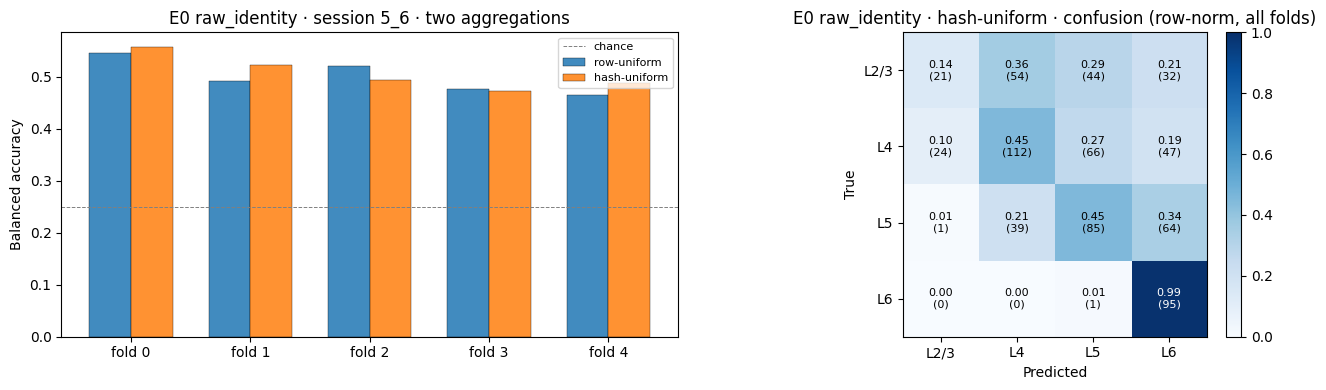

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Per-fold bal-acc, raw_identity, two aggregations
ax = axes[0]
x = np.arange(N_FOLDS); w = 0.35
ax.bar(x - w/2, ba_ru['raw_identity'],  width=w, label='row-uniform',
       color='C0', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.bar(x + w/2, ba_hu['raw_identity'],  width=w, label='hash-uniform',
       color='C1', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.axhline(0.25, color='gray', ls='--', lw=0.7, label='chance')
ax.set_xticks(x); ax.set_xticklabels([f'fold {k}' for k in range(N_FOLDS)])
ax.set_ylabel('Balanced accuracy')
ax.set_title(f'E0 raw_identity · session {SESSION} · two aggregations')
ax.legend(fontsize=8)

# (b) Confusion matrix (sum across folds, hash-uniform, raw_identity)
ax = axes[1]
C = sum(s['confusion_matrix'] for s in results_hu['raw_identity'])
C_norm = C / C.sum(axis=1, keepdims=True).clip(min=1)
im = ax.imshow(C_norm, vmin=0, vmax=1, cmap='Blues')
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        ax.text(j, i, f'{C_norm[i,j]:.2f}\n({C[i,j]})',
                ha='center', va='center', fontsize=8,
                color='white' if C_norm[i,j] > 0.5 else 'black')
ax.set_xticks(range(len(LAYER_CLASSES))); ax.set_xticklabels(LAYER_CLASSES)
ax.set_yticks(range(len(LAYER_CLASSES))); ax.set_yticklabels(LAYER_CLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('E0 raw_identity · hash-uniform · confusion (row-norm, all folds)')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)

plt.tight_layout(); plt.show()

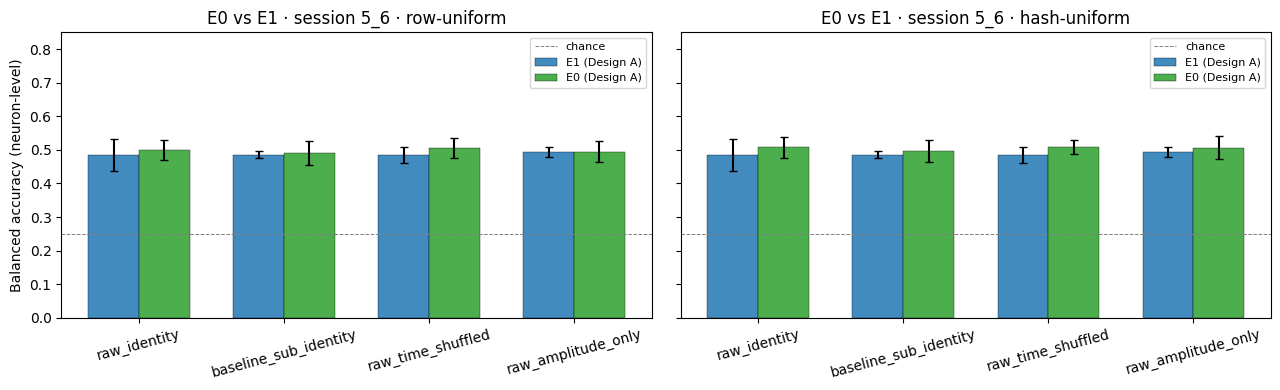

In [10]:
# (c) E0 vs E1 per condition, two aggregations side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
labels = list(model_lookup.keys())
x = np.arange(len(labels)); w = 0.35

for ax, ba_e0, agg in [(axes[0], ba_ru, 'row-uniform'),
                       (axes[1], ba_hu, 'hash-uniform')]:
    e1m = np.array([ba_E1_per_fold[c].mean()      for c in labels])
    e1s = np.array([ba_E1_per_fold[c].std(ddof=0) for c in labels])
    e0m = np.array([ba_e0[c].mean()               for c in labels])
    e0s = np.array([ba_e0[c].std(ddof=0)          for c in labels])
    ax.bar(x - w/2, e1m, w, yerr=e1s, capsize=3, label='E1 (Design A)',
           color='C0', alpha=0.85, edgecolor='k', linewidth=0.3)
    ax.bar(x + w/2, e0m, w, yerr=e0s, capsize=3, label='E0 (Design A)',
           color='C2', alpha=0.85, edgecolor='k', linewidth=0.3)
    ax.axhline(0.25, color='gray', ls='--', lw=0.7, label='chance')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
    ax.set_title(f'E0 vs E1 · session {SESSION} · {agg}')
    if ax is axes[0]:
        ax.set_ylabel('Balanced accuracy (neuron-level)')
    ax.legend(fontsize=8)

y_top = max(0.85, max([ba_ru[c].max() for c in labels] +
                       [ba_hu[c].max() for c in labels]) + 0.05)
for ax in axes: ax.set_ylim(0.0, y_top)
plt.tight_layout(); plt.show()

## 9 · Training curves (raw vs baseline-subtracted, mean ± SD across folds)

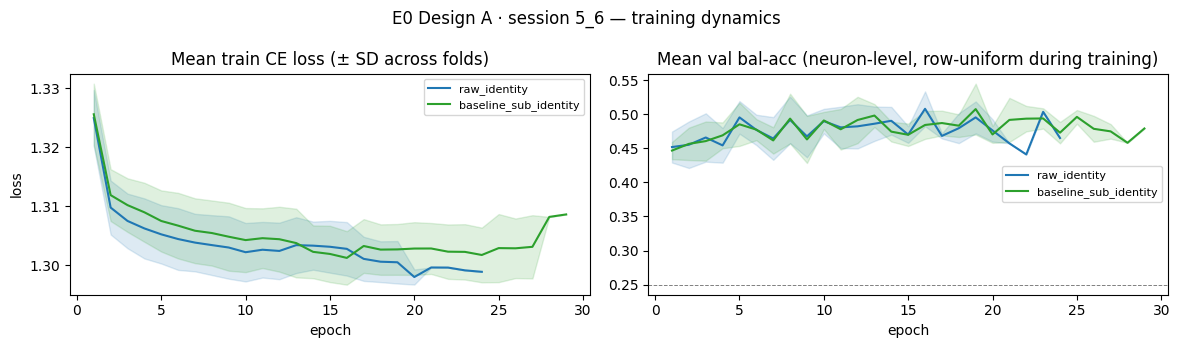

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for label, color in [('raw_identity', 'C0'), ('baseline_sub_identity', 'C2')]:
    hists = histories[label]
    max_e = max(len(h) for h in hists)
    loss = np.full((len(hists), max_e), np.nan)
    vacc = np.full((len(hists), max_e), np.nan)
    for i, h in enumerate(hists):
        loss[i, :len(h)] = [r['train_loss']  for r in h]
        vacc[i, :len(h)] = [r['val_bal_acc'] for r in h]
    epochs = np.arange(1, max_e + 1)
    axes[0].plot(epochs, np.nanmean(loss, 0), color=color, label=label)
    axes[0].fill_between(epochs,
                         np.nanmean(loss, 0) - np.nanstd(loss, 0),
                         np.nanmean(loss, 0) + np.nanstd(loss, 0),
                         color=color, alpha=0.15)
    axes[1].plot(epochs, np.nanmean(vacc, 0), color=color, label=label)
    axes[1].fill_between(epochs,
                         np.nanmean(vacc, 0) - np.nanstd(vacc, 0),
                         np.nanmean(vacc, 0) + np.nanstd(vacc, 0),
                         color=color, alpha=0.15)
axes[0].set(title='Mean train CE loss (± SD across folds)', xlabel='epoch', ylabel='loss')
axes[1].set(title='Mean val bal-acc (neuron-level, row-uniform during training)', xlabel='epoch')
axes[1].axhline(0.25, color='gray', ls='--', lw=0.7)
for ax in axes:
    ax.legend(fontsize=8)
plt.suptitle(f'E0 Design A · session {SESSION} — training dynamics')
plt.tight_layout(); plt.show()

## 10 · Interpretation (per planning §7-Stage 2.2)

We classify the outcome along four axes — above-chance under each aggregation, control deltas under each aggregation, and the E0 vs E1 paired Δ — and produce the corresponding allowed scientific reading. Same conservative thresholds as before (`raw` is considered above-chance only if it beats 0.25 by ≥ 5 pp; a paired Δ is meaningful only if its absolute value exceeds `EPS_DELTA = 0.01`).

In [12]:
EPS_DELTA = 0.01

def axis_readings(ba, ba_E1, agg_label):
    out = []
    raw  = ba['raw_identity'].mean()
    bsub = ba['baseline_sub_identity'].mean()
    shuf = ba['raw_time_shuffled'].mean()
    amp  = ba['raw_amplitude_only'].mean()

    out.append(f'[{agg_label}] raw={raw:.3f}  bsub={bsub:.3f}  shuf={shuf:.3f}  amp={amp:.3f}')

    if raw - 0.25 < 0.05:
        out.append(f'  → FAILURE: E0 raw does not beat chance by ≥ 5 pp under {agg_label}.')
    else:
        out.append(f'  → raw above chance: Δ_chance = {raw - 0.25:+.3f}')

        d_baseline  = raw - bsub
        d_temporal  = raw - shuf
        d_amplitude = raw - amp

        if d_baseline > EPS_DELTA and (bsub - 0.25) < 0.03:
            out.append(f'    OFFSET-DRIVEN: bsub collapses (Δ_baseline = {d_baseline:+.3f}).')
        elif abs(d_baseline) <= EPS_DELTA:
            out.append(f'    Offset is not the driver (Δ_baseline = {d_baseline:+.3f}).')
        elif d_baseline < -EPS_DELTA:
            out.append(f'    bsub IMPROVES over raw (Δ_baseline = {d_baseline:+.3f}).')
        else:
            out.append(f'    Offset contributes some signal (Δ_baseline = {d_baseline:+.3f}).')

        if d_temporal > EPS_DELTA:
            out.append(f'    TEMPORAL ORDER MATTERS (Δ_temporal = {d_temporal:+.3f}).')
        elif abs(d_temporal) <= EPS_DELTA:
            out.append(f'    Temporal order does NOT contribute (Δ_temporal = {d_temporal:+.3f}). '
                       f'Kinetics claims NOT allowed.')
        else:
            out.append(f'    time-shuffled BEATS raw (Δ_temporal = {d_temporal:+.3f}). Suspicious.')

        if d_amplitude > EPS_DELTA:
            out.append(f'    BEYOND AMPLITUDE: raw beats amplitude-only (Δ_amplitude = {d_amplitude:+.3f}).')
        elif abs(d_amplitude) <= EPS_DELTA:
            out.append(f'    AMPLITUDE-EQUIVALENT (Δ_amplitude = {d_amplitude:+.3f}).')
        else:
            out.append(f'    amplitude-only BEATS raw (Δ_amplitude = {d_amplitude:+.3f}).')

    # E0 vs E1 on raw_identity
    d_E0_E1_raw = raw - ba_E1['raw_identity'].mean()
    out.append(f'  E0 vs E1 on raw_identity ({agg_label}): Δ_E0_E1 = {d_E0_E1_raw:+.3f}')
    return out, {
        'raw': raw, 'bsub': bsub, 'shuf': shuf, 'amp': amp,
        'd_baseline': raw - bsub, 'd_temporal': raw - shuf, 'd_amplitude': raw - amp,
        'd_E0_E1_raw': d_E0_E1_raw,
    }

verdict_ru, m_ru = axis_readings(ba_ru, ba_E1_per_fold, 'ROW-uniform')
verdict_hu, m_hu = axis_readings(ba_hu, ba_E1_per_fold, 'HASH-uniform')

print('Stage 2.2 verdict — Design A on E0:\n')
for v in verdict_ru:
    print('  ' + v)
print()
for v in verdict_hu:
    print('  ' + v)

# Cross-aggregation reading (planning §7-Stage 2.2)
print('\n──── Cross-aggregation reading (planning §7-Stage 2.2) ────')
improves_ru = m_ru['d_E0_E1_raw'] >  EPS_DELTA
improves_hu = m_hu['d_E0_E1_raw'] >  EPS_DELTA
worse_both  = m_ru['d_E0_E1_raw'] < -EPS_DELTA and m_hu['d_E0_E1_raw'] < -EPS_DELTA
tie_both    = abs(m_ru['d_E0_E1_raw']) <= EPS_DELTA and abs(m_hu['d_E0_E1_raw']) <= EPS_DELTA

if improves_ru and improves_hu:
    print('  → E0 > E1 under BOTH aggregations: trial-level variability/reliability '
          'contains useful information beyond the within-hash mean.')
    print('    PROCEED to Stage 2.2 step 2 (Design B on E0) and then Stage 2.3 (replication on 5_7).')
elif improves_ru and not improves_hu:
    print('  → E0 improves only under ROW-uniform aggregation: the apparent gain is plausibly '
          'voting weight from oracle-Clip 10-rep hashes, not real trial-level information.')
    print('    Hash-uniform is the safer headline. Design B on E0 is still informative but '
          'expected gains are limited.')
elif worse_both:
    print('  → E0 < E1 under both aggregations: trial noise dominates on this session, trial '
          'averaging (E1) is preferable. Stage 2.2 step 2 (Design B on E0) is unlikely to help; '
          'consider proceeding to Stage 2.3 (E1 on 5_7) instead.')
elif tie_both:
    print('  → E0 ≈ E1 under both aggregations: trial-level information is not decisive on this '
          'session. Proceeding to Stage 2.2 step 2 (Design B on E0) is informative as a sanity '
          'check, but the strong-claim path probably runs through Stage 2.3 / 2.4 instead.')
else:
    print('  → Mixed result across aggregations — interpret each headline separately. '
          'Hash-uniform is the safer scientific headline because it does not over-weight '
          '10-rep oracles.')

Stage 2.2 verdict — Design A on E0:

  [ROW-uniform] raw=0.501  bsub=0.490  shuf=0.506  amp=0.495
    → raw above chance: Δ_chance = +0.251
      Offset contributes some signal (Δ_baseline = +0.010).
      Temporal order does NOT contribute (Δ_temporal = -0.006). Kinetics claims NOT allowed.
      AMPLITUDE-EQUIVALENT (Δ_amplitude = +0.005).
    E0 vs E1 on raw_identity (ROW-uniform): Δ_E0_E1 = +0.016

  [HASH-uniform] raw=0.507  bsub=0.497  shuf=0.509  amp=0.506
    → raw above chance: Δ_chance = +0.257
      Offset contributes some signal (Δ_baseline = +0.011).
      Temporal order does NOT contribute (Δ_temporal = -0.001). Kinetics claims NOT allowed.
      AMPLITUDE-EQUIVALENT (Δ_amplitude = +0.001).
    E0 vs E1 on raw_identity (HASH-uniform): Δ_E0_E1 = +0.023

──── Cross-aggregation reading (planning §7-Stage 2.2) ────
  → E0 > E1 under BOTH aggregations: trial-level variability/reliability contains useful information beyond the within-hash mean.
    PROCEED to Stage 2.2 step 2 (

## 11 · Persist results

Saves one row per `(condition × fold × aggregation)` and one summary row per `(condition × aggregation)` to `data/processed/results/phase2_stage2_2_e0_design_a.parquet`. Downstream notebooks (Stage 2.2 step 2 onwards) join on this file.

In [13]:
rows = []
for label, norm, ctrl in CONDITIONS:
    for agg_label, results in [('row_uniform', results_ru), ('hash_uniform', results_hu)]:
        for k, score in enumerate(results[label]):
            rows.append(make_result_row(
                model_name      = f'CNN_E0_{label}__agg_{agg_label}',
                input_mode      = 'E0_padded_oracle',
                normalization   = norm,
                stimulus_family = 'all_padded',
                split_protocol  = f'within_session_GKF{N_FOLDS}',
                fold_or_session = f'{SESSION}_fold{k}',
                seed            = SEED + k,
                score_dict      = score,
                notes           = (f'Stage 2.2 Design A on E0; control={ctrl}; aggregation={agg_label}; '
                                   'mismatch removed; padded T=113; masked GAP'),
            ))
        s = summarise(results[label])
        rows.append({
            'model_name':        f'CNN_E0_{label}__agg_{agg_label}',
            'input_mode':        'E0_padded_oracle',
            'normalization':     norm,
            'stimulus_family':   'all_padded',
            'split_protocol':    f'within_session_GKF{N_FOLDS}',
            'fold_or_session':   f'{SESSION}_summary',
            'seed':              SEED,
            'n_neurons':         int(np.mean([sc['n_neurons'] for sc in results[label]])),
            'balanced_accuracy': float(s['bal_acc_mean']),
            'macro_f1':          float(s['macro_f1_mean']),
            'recall_L23':        float(s['recall_L2/3_mean']),
            'recall_L4':         float(s['recall_L4_mean']),
            'recall_L5':         float(s['recall_L5_mean']),
            'recall_L6':         float(s['recall_L6_mean']),
            'notes':             (f'Stage 2.2 SUMMARY (mean over {N_FOLDS} folds); control={ctrl}; '
                                  f'aggregation={agg_label}; bal_acc_std={s["bal_acc_std"]:.4f}'),
        })

save_results(rows, 'phase2_stage2_2_e0_design_a.parquet')
print(f'Saved {len(rows)} rows → data/processed/results/phase2_stage2_2_e0_design_a.parquet')

Saved 48 row(s) → data/processed/results/phase2_stage2_2_e0_design_a.parquet  (total: 48)
Saved 48 rows → data/processed/results/phase2_stage2_2_e0_design_a.parquet


---

### What this notebook does NOT claim

* **No cross-session claim.** Within session 5_6 only.
* **No engineered-tier comparison.** Tier-G / Tier-A / multimodal benchmarks are still deferred to the end-of-Phase-2 benchmark notebook.
* **No kinetics claim** unless Δ_temporal > 0 AND Δ_amplitude > 0 under **at least the hash-uniform aggregation**, baseline-subtracted does not collapse, and saliency / occlusion (a future notebook) localises signal to evoked windows (planning §11).

### Next notebook (decided by §10's verdict)

* If `E0 > E1` under both aggregations → **Stage 2.2 step 2: Design B on E0** (set-CNN over per-trial trace embeddings, mean-pool then per-neuron classification). 
* If `E0 ≈ E1` or `E0 < E1` under hash-uniform → skip Design B on E0 and **proceed to Stage 2.3 (replication on 5_7) with E1 / Design B**, since trial-level information does not justify the extra compute on this session.